# Actual numerical rank of the `system_beam` Lanczos basis

This notebook loads the 30,000-dimensional beam system, applies the same Jacobi scaling and effective-box construction as the V3 hull/intersection notebook, and runs the unreorthogonalized three-term Lanczos recurrence with $r_0=\hat b-\hat A c_0$. Unlike a beta-breakdown counter, it measures the **actual numerical rank** of the stored basis $Q_m=[q_1,\ldots,q_m]$.

Every 500 columns, a block-incremental rank-revealing QR test is applied. Each new block is projected twice against the accepted orthonormal range before QR with column pivoting. A residual QR diagonal is accepted when it exceeds $\tau=n\epsilon_{\rm mach}\max_j\lVert q_j\rVert_2$. The run stops when a complete block contributes no new numerical rank, or when $m=n$.

The exact checkpoint values of $\lVert Q_m^TQ_m-I\rVert_F$ and $\lVert Q_m^TQ_m-I\rVert_{\max}$ are accumulated blockwise without retaining the dense Gram matrix. All Lanczos vectors are stored as float64 `.npy` blocks, avoiding a 7.2 GB in-memory allocation.

In [1]:
from pathlib import Path
import gc
import pickle
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import qr, solveh_banded
from scipy.sparse import csr_matrix, diags

with Path("wing_bsm_30k.pkl").open("rb") as file:
    K_full, F_full, U_full, B0_1_full, B0_2_full = pickle.load(file)
A_full = csr_matrix(K_full)
A = A_full[3:, 3:].tocsr()
b = np.asarray(F_full[3:], dtype=float).copy()
stored_solution = np.asarray(U_full[3:], dtype=float).copy()
initial_box = np.asarray(B0_1_full[3:], dtype=float).copy()
if not np.array_equal(B0_1_full[3:], B0_2_full[3:]):
    raise ValueError("The two beam boxes differ after removing BC coordinates.")
del K_full, F_full, U_full, B0_1_full, B0_2_full, A_full
gc.collect()

n = b.size
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
asymmetry = A - A.T
max_asymmetry = 0.0 if asymmetry.nnz == 0 else float(np.max(np.abs(asymmetry.data)))
if max_asymmetry > 100 * np.finfo(float).eps * np.max(np.abs(A.data)):
    raise ValueError(f"A is not numerically symmetric: {max_asymmetry:.3e}.")
del asymmetry

diagonal = A.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = (diags(inverse_scale) @ A @ diags(inverse_scale)).tocsr()
b_hat = inverse_scale * b

rows, columns = A_hat.nonzero()
bandwidth = int(np.max(rows - columns))
A_banded = np.zeros((bandwidth + 1, n), dtype=float)
for offset in range(bandwidth + 1):
    A_banded[offset, : n - offset] = A_hat.diagonal(-offset)
y_star = solveh_banded(A_banded, b_hat, lower=True, check_finite=False)
x_star = inverse_scale * y_star
outside_original_box = (x_star < initial_box[:, 0]) | (x_star > initial_box[:, 1])
effective_box = np.column_stack([
    np.minimum(initial_box[:, 0], x_star),
    np.maximum(initial_box[:, 1], x_star),
])
lower0 = scale * effective_box[:, 0]
upper0 = scale * effective_box[:, 1]
center0 = 0.5 * (lower0 + upper0)
r0 = b_hat - A_hat @ center0

print(f"system dimension n: {n:,}")
print(f"scaled matrix nonzeros: {A_hat.nnz:,}")
print(f"scaled bandwidth: {bandwidth}")
print(f"maximum absolute asymmetry: {max_asymmetry:.3e}")
print(f"coordinates expanded to contain the solution: {outside_original_box.sum():,}")
print(f"starting residual norm ||b_hat-A_hat c0||: {np.linalg.norm(r0):.6e}")

system dimension n: 30,000
scaled matrix nonzeros: 129,994
scaled bandwidth: 4
maximum absolute asymmetry: 0.000e+00
coordinates expanded to contain the solution: 3,334
starting residual norm ||b_hat-A_hat c0||: 6.007248e+08


In [2]:
def actual_rank_lanczos(A, r0, q_block_directory, checkpoint_period=500, rank_relative_tolerance=None):
    """Generate/store Q and measure its rank and orthogonality blockwise."""
    r0 = np.asarray(r0, dtype=float)
    n = A.shape[0]
    if A.shape != (n, n) or r0.shape != (n,):
        raise ValueError("Incompatible matrix and starting-vector dimensions.")
    if checkpoint_period <= 0:
        raise ValueError("checkpoint_period must be positive.")
    r0_norm = float(np.linalg.norm(r0))
    if not np.isfinite(r0_norm) or r0_norm == 0.0:
        raise ValueError("r0 must be finite and nonzero.")

    eps = np.finfo(float).eps
    if rank_relative_tolerance is None:
        rank_relative_tolerance = n * eps
    rank_relative_tolerance = float(rank_relative_tolerance)
    if rank_relative_tolerance <= 0.0:
        raise ValueError("rank_relative_tolerance must be positive.")
    q_block_directory = Path(q_block_directory)
    q_block_directory.mkdir(parents=True, exist_ok=True)

    q_previous = np.zeros(n, dtype=float)
    q = r0 / r0_norm
    beta_j = 0.0
    operator_scale = float(np.max(np.asarray(np.abs(A).sum(axis=1)).ravel()))
    breakdown_tolerance = 100 * eps * operator_scale

    steps, ranks, increments, absolute_tolerances = [], [], [], []
    gram_fro_errors, gram_max_errors, gram_max_offdiag_errors = [], [], []
    q_block_paths, basis_paths = [], []
    accepted_rank = 0
    gram_fro_sq = 0.0
    gram_max = 0.0
    gram_max_offdiag = 0.0
    maximum_q_norm = 0.0
    breakdown_step = None
    stopped_for_rank_stagnation = False
    started = time.perf_counter()

    # The accepted orthonormal range is disk-backed and temporary. Only the
    # requested raw Lanczos Q blocks persist after execution.
    with tempfile.TemporaryDirectory(prefix="beam_lanczos_rrqr_") as tmp:
        basis_directory = Path(tmp)
        for block_start in range(0, n, checkpoint_period):
            requested = min(checkpoint_period, n - block_start)
            q_block = np.empty((n, requested), dtype=float, order="F")
            generated = 0
            for local_column in range(requested):
                global_step = block_start + local_column + 1
                q_block[:, local_column] = q
                generated += 1
                w = A @ q - beta_j * q_previous
                alpha_j = float(q @ w)
                w -= alpha_j * q
                beta_next = float(np.linalg.norm(w))
                if global_step == n:
                    break
                if not np.isfinite(beta_next) or beta_next <= breakdown_tolerance:
                    breakdown_step = global_step
                    break
                q_previous, q = q, w / beta_next
                beta_j = beta_next

            q_block = np.asfortranarray(q_block[:, :generated])
            checkpoint = block_start + generated
            block_path = q_block_directory / f"q_{block_start + 1:06d}_{checkpoint:06d}.npy"
            np.save(block_path, q_block, allow_pickle=False)

            # Exact blockwise orthogonality metrics, without storing Q^T Q.
            within_gram = q_block.T @ q_block
            within_error = within_gram - np.eye(generated)
            gram_fro_sq += float(np.sum(within_error * within_error))
            gram_max = max(gram_max, float(np.max(np.abs(within_error), initial=0.0)))
            within_offdiag = within_error.copy()
            np.fill_diagonal(within_offdiag, 0.0)
            gram_max_offdiag = max(
                gram_max_offdiag, float(np.max(np.abs(within_offdiag), initial=0.0))
            )
            for previous_path in q_block_paths:
                previous_q = np.load(previous_path, mmap_mode="r")
                cross_gram = previous_q.T @ q_block
                gram_fro_sq += 2.0 * float(np.sum(cross_gram * cross_gram))
                cross_max = float(np.max(np.abs(cross_gram), initial=0.0))
                gram_max = max(gram_max, cross_max)
                gram_max_offdiag = max(gram_max_offdiag, cross_max)
                del previous_q, cross_gram

            q_norms = np.sqrt(np.diag(within_gram))
            maximum_q_norm = max(maximum_q_norm, float(np.max(q_norms)))
            absolute_tolerance = rank_relative_tolerance * maximum_q_norm

            # Two-pass block Gram-Schmidt plus column-pivoted QR.
            residual_block = q_block.copy(order="F")
            for _ in range(2):
                for basis_path in basis_paths:
                    basis = np.load(basis_path, mmap_mode="r")
                    coefficients = basis.T @ residual_block
                    residual_block -= basis @ coefficients
                    del basis, coefficients
            residual_q, triangular, pivots = qr(
                residual_block, mode="economic", pivoting=True,
                overwrite_a=True, check_finite=False,
            )
            qr_diagonal = np.abs(np.diag(triangular))
            increment = int(np.count_nonzero(qr_diagonal > absolute_tolerance))
            if increment:
                new_basis = np.asfortranarray(residual_q[:, :increment])
                basis_path = basis_directory / f"z_{len(basis_paths):04d}.npy"
                np.save(basis_path, new_basis, allow_pickle=False)
                basis_paths.append(basis_path)
                accepted_rank += increment
                del new_basis

            q_block_paths.append(block_path)
            steps.append(checkpoint)
            ranks.append(accepted_rank)
            increments.append(increment)
            absolute_tolerances.append(absolute_tolerance)
            gram_fro_errors.append(np.sqrt(gram_fro_sq))
            gram_max_errors.append(gram_max)
            gram_max_offdiag_errors.append(gram_max_offdiag)
            print(
                f"m={checkpoint:6,d}  rank(Q_m)={accepted_rank:6,d}  "
                f"increment={increment:4,d}  tol={absolute_tolerance:.3e}  "
                f"||Q^TQ-I||_F={gram_fro_errors[-1]:.3e}  "
                f"||.||_max={gram_max_errors[-1]:.3e}  "
                f"time={time.perf_counter() - started:.1f}s"
            )
            del q_block, within_gram, within_error, within_offdiag
            del residual_block, residual_q, triangular, pivots
            gc.collect()
            if increment == 0:
                stopped_for_rank_stagnation = True
                break
            if breakdown_step is not None or checkpoint == n:
                break

    return {
        "n": n,
        "checkpoint_period": checkpoint_period,
        "checkpoint_steps": np.asarray(steps, dtype=int),
        "numerical_ranks": np.asarray(ranks, dtype=int),
        "rank_increments": np.asarray(increments, dtype=int),
        "rank_relative_tolerance": rank_relative_tolerance,
        "absolute_rank_tolerances": np.asarray(absolute_tolerances),
        "gram_frobenius_errors": np.asarray(gram_fro_errors),
        "gram_max_errors": np.asarray(gram_max_errors),
        "gram_max_offdiagonal_errors": np.asarray(gram_max_offdiag_errors),
        "q_block_paths": np.asarray([str(path) for path in q_block_paths]),
        "operator_scale": operator_scale,
        "breakdown_tolerance": breakdown_tolerance,
        "breakdown_step": breakdown_step,
        "stopped_for_rank_stagnation": stopped_for_rank_stagnation,
        "elapsed_seconds": time.perf_counter() - started,
    }

In [3]:
checkpoint_period = 500
results_directory = Path("system_beam_lanczos_results")
q_block_directory = results_directory / "actual_rank_q_blocks"
result = actual_rank_lanczos(
    A=A_hat, r0=r0, q_block_directory=q_block_directory,
    checkpoint_period=checkpoint_period,
)
result["starting_vector_description"] = np.asarray("b_hat - A_hat @ center0")
result["starting_residual_norm"] = np.asarray(np.linalg.norm(r0))
result["expanded_coordinate_count"] = np.asarray(outside_original_box.sum())
print()
print(f"last generated prefix m: {result['checkpoint_steps'][-1]:,}")
print(f"final numerical rank: {result['numerical_ranks'][-1]:,}")
print(f"relative rank tolerance: {result['rank_relative_tolerance']:.6e}")
print(f"absolute rank tolerance: {result['absolute_rank_tolerances'][-1]:.6e}")
print(f"stopped for rank stagnation: {result['stopped_for_rank_stagnation']}")
print(f"Lanczos beta breakdown step: {result['breakdown_step']}")
print(f"stored Q blocks: {len(result['q_block_paths'])}")
print(f"elapsed time: {result['elapsed_seconds']:.2f} s")

m=   500  rank(Q_m)=   473  increment= 473  tol=6.661e-12  ||Q^TQ-I||_F=2.121e+01  ||.||_max=5.413e-01  time=1.0s


m= 1,000  rank(Q_m)=   944  increment= 471  tol=6.661e-12  ||Q^TQ-I||_F=4.238e+01  ||.||_max=5.432e-01  time=4.2s


m= 1,500  rank(Q_m)= 1,415  increment= 471  tol=6.661e-12  ||Q^TQ-I||_F=6.361e+01  ||.||_max=5.432e-01  time=7.7s


m= 2,000  rank(Q_m)= 1,887  increment= 472  tol=6.661e-12  ||Q^TQ-I||_F=8.414e+01  ||.||_max=5.432e-01  time=12.0s


m= 2,500  rank(Q_m)= 2,360  increment= 473  tol=6.661e-12  ||Q^TQ-I||_F=1.047e+02  ||.||_max=5.434e-01  time=17.1s


...

m=28,000  rank(Q_m)=21,758  increment= 339  tol=6.661e-12  ||Q^TQ-I||_F=1.203e+03  ||.||_max=5.600e-01  time=1680.1s


m=28,500  rank(Q_m)=22,096  increment= 338  tol=6.661e-12  ||Q^TQ-I||_F=1.225e+03  ||.||_max=5.600e-01  time=1742.4s


m=29,000  rank(Q_m)=22,434  increment= 338  tol=6.661e-12  ||Q^TQ-I||_F=1.247e+03  ||.||_max=5.600e-01  time=1803.3s


m=29,500  rank(Q_m)=22,772  increment= 338  tol=6.661e-12  ||Q^TQ-I||_F=1.268e+03  ||.||_max=5.600e-01  time=1865.5s


m=30,000  rank(Q_m)=23,110  increment= 338  tol=6.661e-12  ||Q^TQ-I||_F=1.290e+03  ||.||_max=5.600e-01  time=1931.2s

last generated prefix m: 30,000
final numerical rank: 23,110
relative rank tolerance: 6.661338e-12
absolute rank tolerance: 6.661338e-12
stopped for rank stagnation: False
Lanczos beta breakdown step: None
stored Q blocks: 60
elapsed time: 1931.31 s


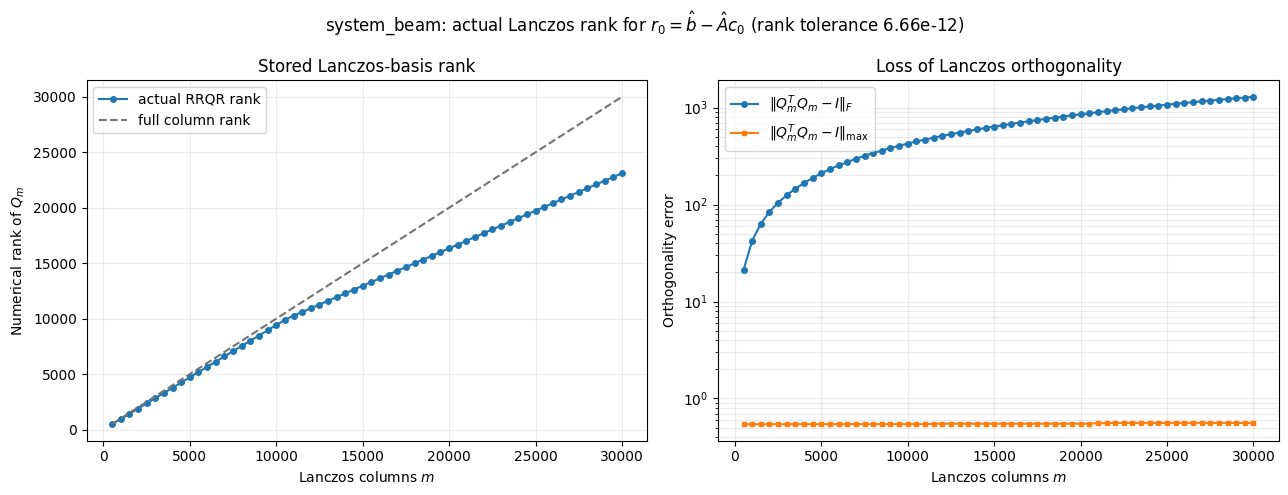

saved system_beam_lanczos_results/actual_rank_and_orthogonality.png
saved system_beam_lanczos_results/actual_rank_history.npz
stored Q blocks in system_beam_lanczos_results/actual_rank_q_blocks


In [4]:
steps = result["checkpoint_steps"]
ranks = result["numerical_ranks"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(steps, ranks, marker="o", markersize=4, label="actual RRQR rank")
axes[0].plot(steps, steps, "--", color="0.45", label="full column rank")
axes[0].set(xlabel="Lanczos columns $m$", ylabel=r"Numerical rank of $Q_m$", title="Stored Lanczos-basis rank")
axes[0].legend()
tiny = np.finfo(float).tiny
axes[1].semilogy(steps, np.maximum(result["gram_frobenius_errors"], tiny), marker="o", markersize=4, label=r"$\|Q_m^TQ_m-I\|_F$")
axes[1].semilogy(steps, np.maximum(result["gram_max_errors"], tiny), marker="s", markersize=3, label=r"$\|Q_m^TQ_m-I\|_{\max}$")
axes[1].set(xlabel="Lanczos columns $m$", ylabel="Orthogonality error", title="Loss of Lanczos orthogonality")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25, which="both")
fig.suptitle(r"system_beam: actual Lanczos rank for $r_0=\hat b-\hat A c_0$ " + f"(rank tolerance {result['absolute_rank_tolerances'][-1]:.2e})")
fig.tight_layout()
results_directory.mkdir(exist_ok=True)
figure_path = results_directory / "actual_rank_and_orthogonality.png"
data_path = results_directory / "actual_rank_history.npz"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
np.savez_compressed(data_path, **{key: value for key, value in result.items() if value is not None})
plt.show()
print(f"saved {figure_path}")
print(f"saved {data_path}")
print(f"stored Q blocks in {q_block_directory}")